In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from importlib import reload

import seaborn as sns
from collections import defaultdict
from tqdm import tqdm
import inspect
import time
import os

sys.path.append('/Users/cheungjustin/PycharmProjects/CIBer')
import util as put
import stats as pstats
import analytics as pan
import plot as pplot

In [2]:
model_excludes = []#'CIBerNew', 'CIBerOld']
scores = {}

for f in os.listdir():
    fname, fext =  os.path.splitext(f)
    if fext == '.csv':
        scores[fname] = pd.read_csv(f, index_col=0, header=[0, 1])

scores = pd.concat(scores, names=['dataset'])
scores = scores.drop(columns=model_excludes, level='model')
scores

model                                  CIBerFS                      CIBerNew  \
stat                                 precision    recall  f1-score precision   
dataset                         iter                                           
smart_logistics_Logistics_Delay 0     1.000000  1.000000  1.000000  0.975164   
                                1     1.000000  1.000000  1.000000  0.975490   
                                2     1.000000  1.000000  1.000000  0.979798   
                                3     1.000000  1.000000  1.000000  0.961445   
                                4     1.000000  1.000000  1.000000  0.964745   
...                                        ...       ...       ...       ...   
income_occupation               45    0.353057  0.336329  0.328739  0.380260   
                                46    0.360628  0.332856  0.332187  0.385251   
                                47    0.382786  0.335262  0.328999  0.387509   
                                48    0.360993  0.328317  0.319373  0.374644   
                                49    0.353100  0.339754  0.334872  0.386044   

model                                                     CIBerOld            \
stat                                    recall  f1-score precision    recall   
dataset                         iter                                           
smart_logistics_Logistics_Delay 0     0.973657  0.974385  0.991453  0.988235   
                                1     0.975728  0.974999  0.975490  0.975728   
                                2     0.979798  0.979798  0.986726  0.983333   
                                3     0.968335  0.964248  1.000000  1.000000   
                                4     0.954476  0.958661  1.000000  1.000000   
...                                        ...       ...       ...       ...   
income_occupation               45    0.308724  0.300391  0.321371  0.325479   
                                46    0.309962  0.301501  0.336312  0.319691   
                                47    0.308695  0.298265  0.328387  0.313171   
                                48    0.308715  0.295102  0.324119  0.315916   
                                49    0.317986  0.309823  0.322613  0.321078   

model                                                 NB  ...       LDA  \
stat                                  f1-score precision  ...  f1-score   
dataset                         iter                      ...             
smart_logistics_Logistics_Delay 0     0.989737  1.000000  ...  1.000000   
                                1     0.974999  1.000000  ...  1.000000   
                                2     0.984799  1.000000  ...  1.000000   
                                3     1.000000  1.000000  ...  1.000000   
                                4     1.000000  0.995690  ...  1.000000   
...                                        ...       ...  ...       ...   
income_occupation               45    0.309400  0.345187  ...  0.313888   
                                46    0.313804  0.349588  ...  0.317946   
                                47    0.300944  0.345943  ...  0.311641   
                                48    0.308924  0.339309  ...  0.313587   
                                49    0.312212  0.343885  ...  0.318944   

model                                  LDA_PCA                      \
stat                                 precision    recall  f1-score   
dataset                         iter                                 
smart_logistics_Logistics_Delay 0     1.000000  1.000000  1.000000   
                                1     1.000000  1.000000  1.000000   
                                2     1.000000  1.000000  1.000000   
                                3     1.000000  1.000000  1.000000   
                                4     1.000000  1.000000  1.000000   
...                                        ...       ...       ...   
income_occupation               45    0.325736  0.409889  0.311860   
       

In [3]:
model_rank = scores.groupby('stat', axis=1).rank(ascending=False, method='min')
model_rank_avg = model_rank.groupby('dataset').mean()

/var/folders/cm/9l2pfgfj3c7b3t18cyph49580000gn/T/ipykernel_32606/1171969301.py:1: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  model_rank = scores.groupby('stat', axis=1).rank(ascending=False, method='min')


/var/folders/cm/9l2pfgfj3c7b3t18cyph49580000gn/T/ipykernel_32606/3449267281.py:1: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  for stat, r in model_rank_avg.groupby('stat', axis=1, sort=False):


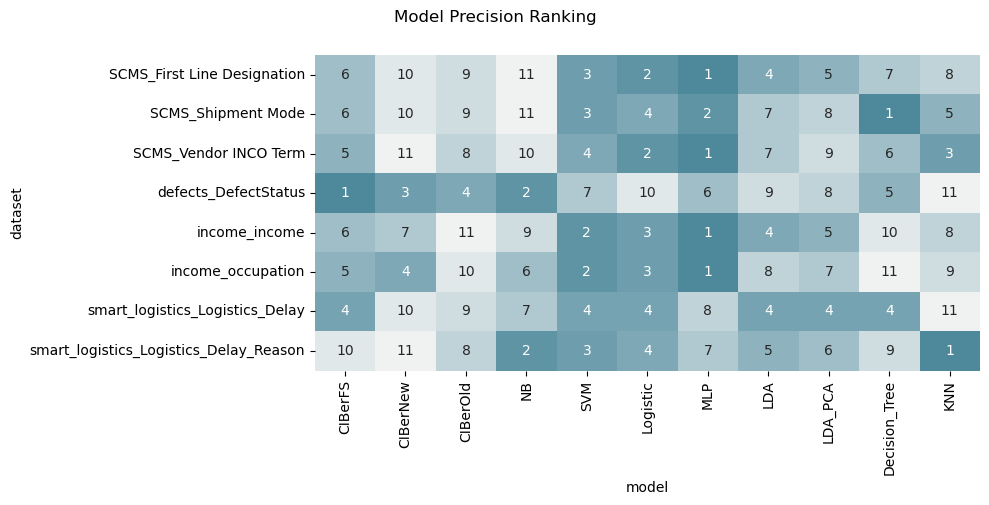

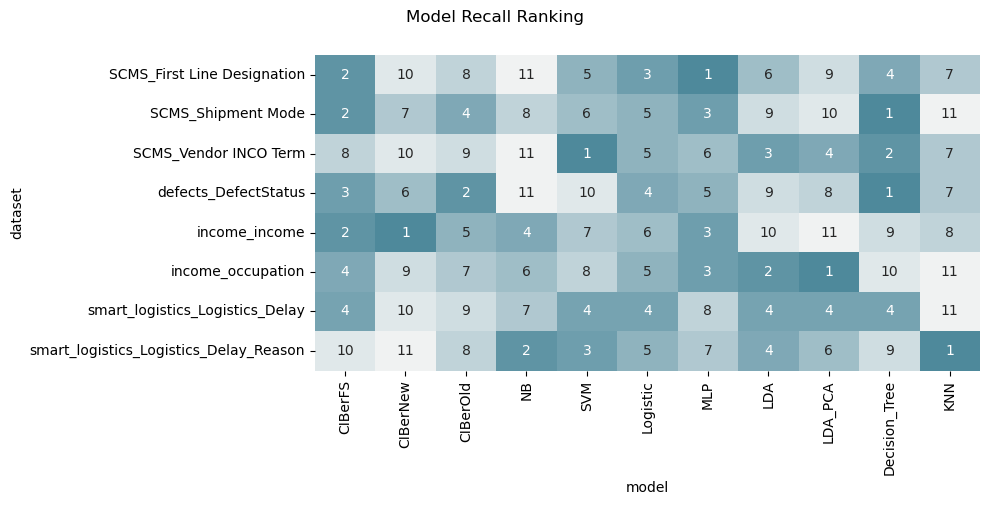

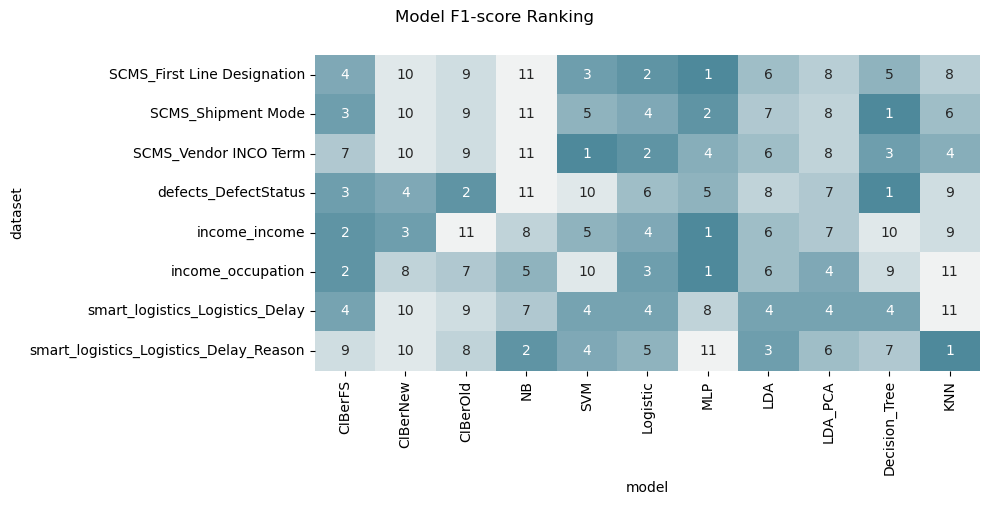

In [4]:
for stat, r in model_rank_avg.groupby('stat', axis=1, sort=False):
    r = r.xs(stat, level='stat', axis=1)
    r = r.rank(axis=1)
    n_model = r.shape[1]
    pplot.heatmap(n_model - r, annot=r, center=0, vmax=n_model,
                 title=f'Model {stat.capitalize()} Ranking', fmt='.0f')

/var/folders/cm/9l2pfgfj3c7b3t18cyph49580000gn/T/ipykernel_32606/422344992.py:3: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  for stat, s in scores_median.groupby('stat', axis=1, sort=False):


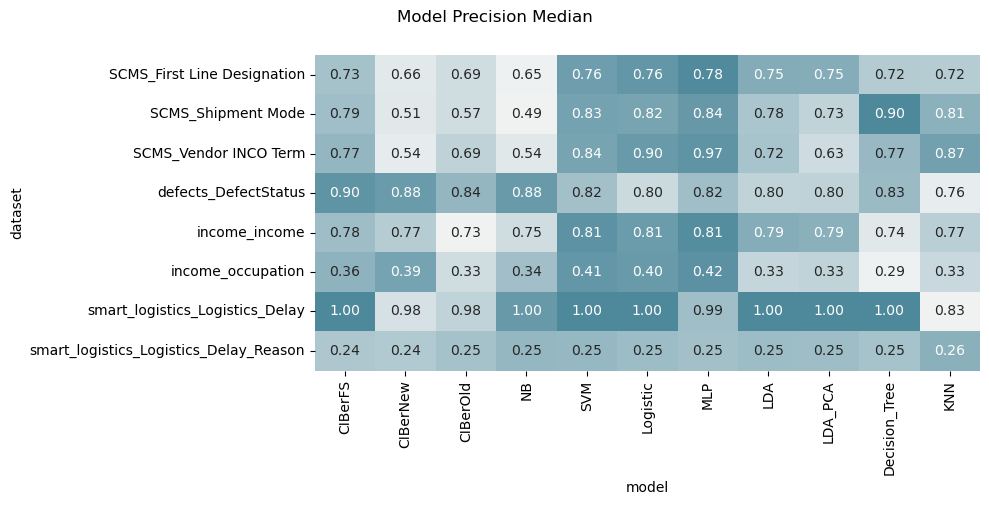

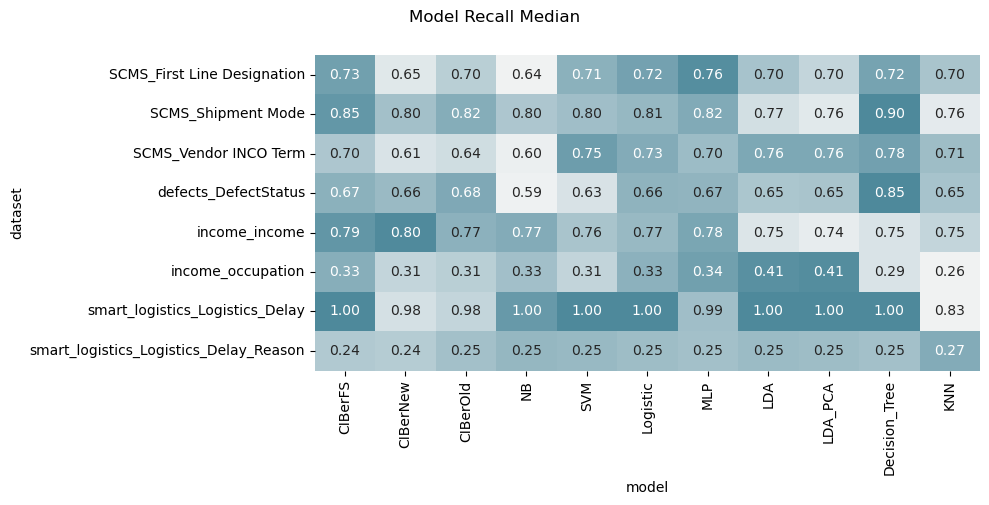

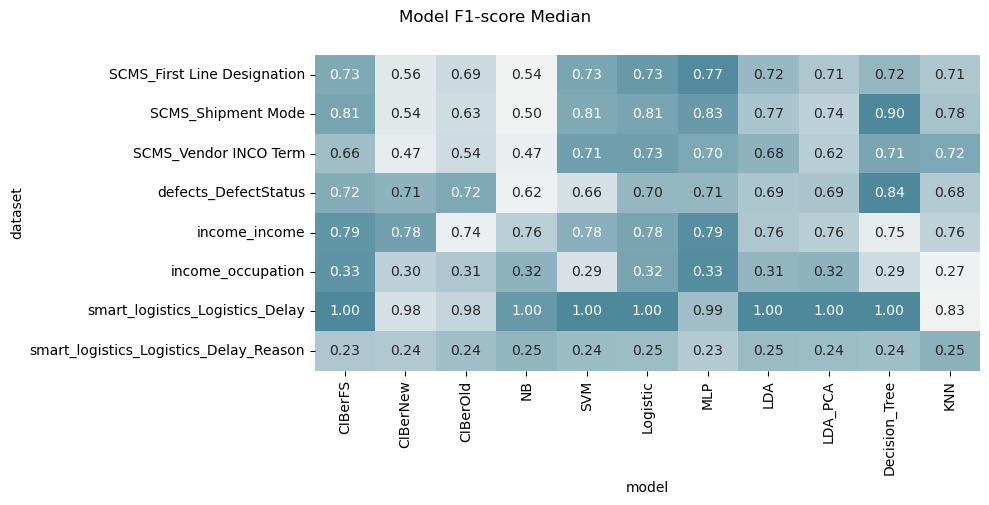

In [11]:
scores_median = scores.groupby('dataset').median()

for stat, s in scores_median.groupby('stat', axis=1, sort=False):
    s = s.xs(stat, level='stat', axis=1)
    r = model_rank_avg.xs(stat, level='stat', axis=1)
    pplot.heatmap(n_model - r, annot=s, center=0, vmax=n_model, 
                 title=f'Model {stat.capitalize()} Median', fmt='.2f')